<a href="https://colab.research.google.com/github/Harshal-Bsys27/MachineLearning_prac/blob/main/DL_eXP_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:

# Experiment No. 2
# Single Layer Feedforward Neural Network using SGD

# Step 1 : Import Libraries
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [3]:
# Step 2 : Load Dataset
data = load_breast_cancer()

X = data.data
y = data.target

print("Number of Samples :", X.shape[0])
print("Number of Features :", X.shape[1])


Number of Samples : 569
Number of Features : 30


In [4]:
# Step 3 : Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [6]:
# Step 4 : Normalize Data
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [7]:
# Step 5 : Build Single Layer Neural Network
model = tf.keras.Sequential([
    tf.keras.layers.Dense(
        units=1,
        activation='sigmoid',
        input_shape=(30,)
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
# Step 6 : Compile Model using SGD Optimizer
optimizer = tf.keras.optimizers.SGD(
    learning_rate=0.01
)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [9]:
# Step 7 : Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=1,     # SGD updates after every sample
    validation_split=0.2,
    verbose=1
)


Epoch 1/50
364/364 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8846 - loss: 0.3136 - val_accuracy: 0.9451 - val_loss: 0.1732
Epoch 2/50
364/364 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9698 - loss: 0.1299 - val_accuracy: 0.9451 - val_loss: 0.1401
Epoch 3/50
364/364 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9780 - loss: 0.1073 - val_accuracy: 0.9560 - val_loss: 0.1276
Epoch 4/50
364/364 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9780 - loss: 0.0962 - val_accuracy: 0.9560 - val_loss: 0.1210
Epoch 5/50
364/364 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9780 - loss: 0.0893 - val_accuracy: 0.9451 - val_loss: 0.1177
Epoch 6/50
364/364 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9808 - loss: 0.0839 - val_accuracy: 0.9560 - val_loss: 0.1160
Epoch 7/50
364/364 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9835 - loss: 0.0806 - val_accuracy: 0.9560 - val_loss: 0.1134
Epoch 8/50
364/364 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9835 - loss: 0.0775 - val_accuracy: 0.

In [10]:
# Step 8 : Evaluate Model
loss, accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("\nTest Accuracy :", accuracy*100,"%")
print("Test Loss :", loss)


Test Accuracy : 97.36841917037964 %
Test Loss : 0.05942000448703766


In [11]:
# Step 9 : Make Predictions
predictions = model.predict(X_test)

predictions = (predictions > 0.5).astype(int)

print("\nFirst 10 Predictions")

for i in range(10):
    print("Actual =", y_test[i],
          " Predicted =", predictions[i][0])


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step

First 10 Predictions
Actual = 1  Predicted = 1
Actual = 0  Predicted = 0
Actual = 0  Predicted = 0
Actual = 1  Predicted = 1
Actual = 1  Predicted = 1
Actual = 0  Predicted = 0
Actual = 0  Predicted = 0
Actual = 0  Predicted = 0
Actual = 1  Predicted = 1
Actual = 1  Predicted = 1


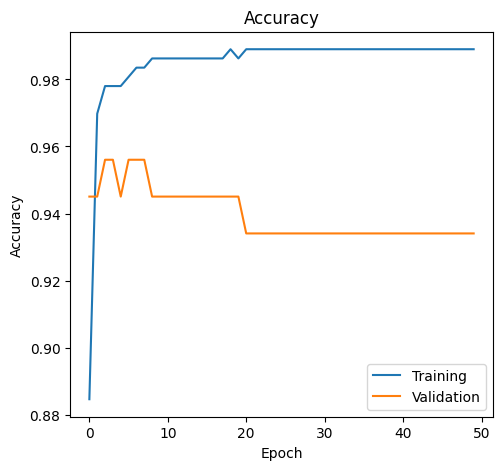

In [12]:
# Step 10 : Plot Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')

plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

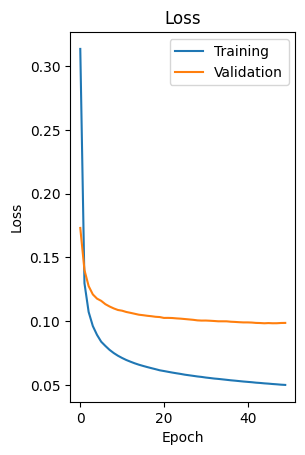

In [13]:
# Step 11 : Plot Loss
plt.subplot(1,2,2)

plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')

plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()


In [14]:
# Step 12 : Display Learned Parameters

weights, bias = model.layers[0].get_weights()

print("\nLearned Weights:\n")
print(weights)

print("\nLearned Bias:\n")
print(bias)


Learned Weights:

[[-0.7356624 ]
 [-0.52258897]
 [-0.41218564]
 [-0.32668746]
 [-0.7327803 ]
 [ 0.28666365]
 [-0.6394138 ]
 [-0.6241876 ]
 [ 0.25574204]
 [ 0.21558945]
 [-0.9362454 ]
 [ 0.04216198]
 [-1.214939  ]
 [-1.0365305 ]
 [-0.21866542]
 [ 0.7658864 ]
 [ 0.17262137]
 [ 0.07526158]
 [ 0.47151318]
 [ 0.18038501]
 [-1.0211079 ]
 [-1.5808991 ]
 [-0.7885672 ]
 [-0.82709235]
 [-0.38853076]
 [ 0.16004618]
 [-0.78811294]
 [-1.2895745 ]
 [-1.0752661 ]
 [-0.19427416]]

Learned Bias:

[0.5770922]
